# Use the Pretrained BT Super-Resolution Models

This notebook is the beginner-friendly path for users who mainly want to load a released model, read an HDF5 brightness-temperature file, and generate a high-resolution prediction. It uses the `.keras` release artifacts through the repository loader so Kelvin normalization is handled for you.

## 1. Setup

Run this notebook from the repository root, or update `REPO_ROOT` below. The model files should be downloaded from the GitHub Release and placed in `release_assets/`.

In [8]:
from pathlib import Path
import sys

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "src").exists():
    REPO_ROOT = Path.cwd().parents[1]

sys.path.insert(0, str(REPO_ROOT / "src"))
print(REPO_ROOT)

/Volumes/被窝冒险家/scratch.kchen137-project/kaitouchen-website/satellite-bt-super-resolution


In [9]:
import h5py
import matplotlib.pyplot as plt
import numpy as np

from bt_super_resolution import load_keras_generator

## 2. Load a Released Keras Model

Use the MW-SR model for a conservative reconstruction-first result, or switch to `configs/rrdn_gan_batchnorm.yaml` for the MW-SR-GAN generator.

In [10]:
CONFIG = REPO_ROOT / "configs/rrdn_composite_ssim_alpha_0.8.yaml"
# CONFIG = REPO_ROOT / "configs/rrdn_gan_batchnorm.yaml"

bundle = load_keras_generator(CONFIG, repository_root=REPO_ROOT)
print(bundle.name)

MW-SR


## 3. HDF5 Helpers

The repository supports files where the low-resolution brightness temperature is stored as `L/bt` or `bt`. Some files also include latitude and longitude arrays; these are optional for prediction but useful for plotting.

In [11]:
LR_KEYS = ("L/bt", "bt")

def find_lr_key(handle):
    for key in LR_KEYS:
        if key in handle:
            return key
    raise KeyError(f"No LR BT dataset found. Checked: {LR_KEYS}")

def read_lr_bt(path):
    with h5py.File(path, "r") as handle:
        key = find_lr_key(handle)
        bt = np.asarray(handle[key][:], dtype=np.float32)
    return bt

def first_h5(path):
    path = Path(path)
    if path.is_file():
        return path
    files = sorted([*path.rglob("*.h5"), *path.rglob("*.hdf5")]) if path.exists() else []
    return files[0] if files else None

def plot_lr_and_prediction(lr_bt, prediction_bt, title):
    lr_2d = lr_bt[0] if lr_bt.ndim == 3 else lr_bt
    pred_2d = prediction_bt[0] if prediction_bt.ndim == 3 else prediction_bt
    vmin, vmax = np.nanpercentile(np.concatenate([lr_2d.ravel(), pred_2d.ravel()]), [1, 99])
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    for ax, panel, label in zip(axes, [lr_2d, pred_2d], ["Input LR", "Predicted HR"]):
        image = ax.imshow(panel, cmap="turbo", vmin=vmin, vmax=vmax)
        ax.set_title(label)
        ax.set_axis_off()
        fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04, label="Brightness Temp. (K)")
    fig.suptitle(title)
    fig.tight_layout()
    return fig

## 4. Run the Public AMSR2 Example

This file is intentionally small enough to keep in Git and is useful for checking that the model and environment work.

LR shape: (96, 100)
Prediction shape: (384, 400)


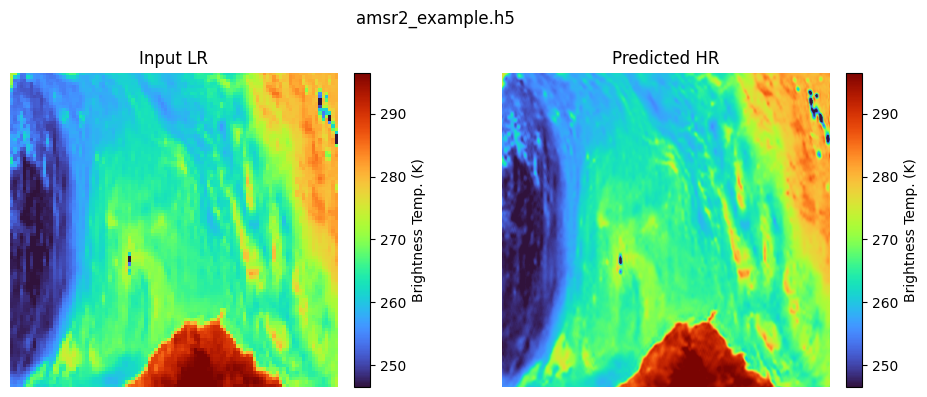

In [12]:
amsr2_example = REPO_ROOT / "sample_data/amsr2_example.h5"
lr_bt = read_lr_bt(amsr2_example)
prediction_bt = bundle.predict_kelvin(lr_bt, batch_size=1)

print("LR shape:", lr_bt.shape)
print("Prediction shape:", prediction_bt.shape)
plot_lr_and_prediction(lr_bt, prediction_bt, amsr2_example.name);

## 5. Optional Local Sensor Collections

The following cells run only if the corresponding local folders exist. These larger folders should not be committed to Git. They are examples for users who have their own compatible HDF5 files.


AMSR2 local collection: /Volumes/被窝冒险家/scratch.kchen137-project/kaitouchen-website/satellite-bt-super-resolution/AMSR2/20260409_031713_032605.h5
LR shape: (96, 100) Prediction shape: (384, 400)


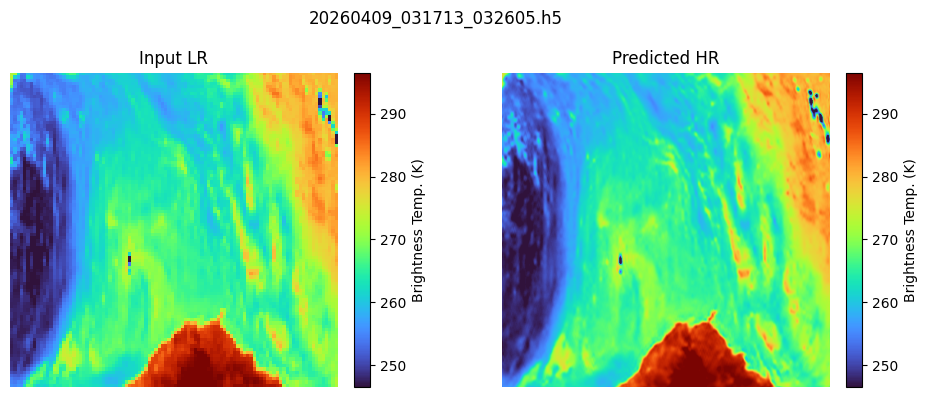


ATMS local collection: /Volumes/被窝冒险家/scratch.kchen137-project/kaitouchen-website/satellite-bt-super-resolution/ATMS/jpss1/jpss1.20260409.b43468.h5
LR shape: (84, 96) Prediction shape: (336, 384)


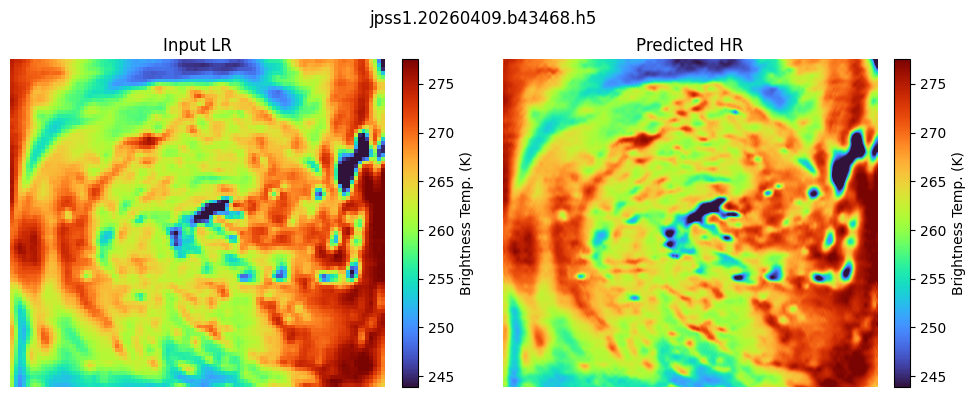


Tomorrow.io local collection: /Volumes/被窝冒险家/scratch.kchen137-project/kaitouchen-website/satellite-bt-super-resolution/tomorrow.io.new/TMS02.1C-TCR.V01-00.NRT.ST20260409-005146.ET20260409-010332.CT20260409-011553.nc.h5
LR shape: (128, 164) Prediction shape: (512, 656)


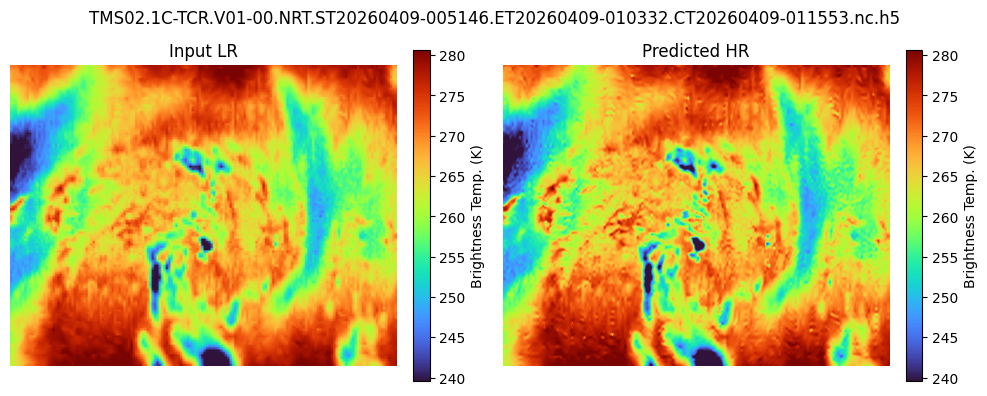

In [13]:
sensor_roots = {
    "AMSR2 local collection": REPO_ROOT / "AMSR2",
    "ATMS local collection": REPO_ROOT / "ATMS",
    "Tomorrow.io local collection": REPO_ROOT / "tomorrow.io.new",
}

for label, root in sensor_roots.items():
    example = first_h5(root)
    if example is None:
        print(f"Skipping {label}: {root} not found or contains no HDF5 files.")
        continue
    print(f"\n{label}: {example}")
    lr_bt = read_lr_bt(example)
    prediction_bt = bundle.predict_kelvin(lr_bt, batch_size=1)
    print("LR shape:", lr_bt.shape, "Prediction shape:", prediction_bt.shape)
    plot_lr_and_prediction(lr_bt, prediction_bt, example.name)
    plt.show()

## 6. Raw ATMS GitHub Case Data

This section mirrors the logic from `github_case/atms_example.py`, adjusted for the current repository layout where the raw ATMS case files live in the project-root `data/` directory. It reads matching `GATMO` geolocation files and `SATMS` brightness-temperature files, extracts ATMS channel 16 near 89 GHz, and runs the released model on that single-channel BT field.

If `cartopy` is installed, the helper below draws coastlines and map features. If not, it falls back to a plain longitude/latitude plot.

In [ ]:
from scipy.ndimage import zoom

RAW_ATMS_DATA_DIR = REPO_ROOT / "github_case" / "data"

def read_raw_atms_channel16(data_dir=RAW_ATMS_DATA_DIR):
    data_dir = Path(data_dir)
    geo_files = sorted(data_dir.glob("GATMO_j01_d20260415*.h5"))
    sdr_files = sorted(data_dir.glob("SATMS_j01_d20260415*.h5"))
    if not geo_files or not sdr_files:
        raise FileNotFoundError(
            f"Expected raw ATMS GATMO/SATMS files under {data_dir}. "
            "Run this from the repository root or update RAW_ATMS_DATA_DIR."
        )

    sdr_handles = [h5py.File(filename, "r") for filename in sdr_files]
    geo_handles = [h5py.File(filename, "r") for filename in geo_files]
    try:
        brightness_temperature = np.concatenate([
            handle["/All_Data/ATMS-SDR_All/BrightnessTemperature"][:]
            for handle in sdr_handles
        ])
        bt_factors = np.concatenate([
            handle["/All_Data/ATMS-SDR_All/BrightnessTemperatureFactors"][:]
            for handle in sdr_handles
        ])
        brightness_temperature = brightness_temperature * bt_factors[0] + bt_factors[1]
        bt_channel16 = brightness_temperature[:, :, 15].astype(np.float32)

        latitude = np.concatenate([
            handle["/All_Data/ATMS-SDR-GEO_All/Latitude"][:]
            for handle in geo_handles
        ]).astype(np.float32)
        longitude = np.concatenate([
            handle["/All_Data/ATMS-SDR-GEO_All/Longitude"][:]
            for handle in geo_handles
        ]).astype(np.float32)
    finally:
        for handle in [*sdr_handles, *geo_handles]:
            handle.close()

    return longitude, latitude, bt_channel16

def swath_extent(longitude, latitude, margin=0.0):
    if (np.nanmax(longitude) - np.nanmin(longitude)) > 180:
        lon_shifted = np.mod(longitude, 360)
        lon_min = (np.nanmin(lon_shifted) - margin + 180) % 360 - 180
        lon_max = (np.nanmax(lon_shifted) + margin + 180) % 360 - 180
    else:
        lon_min = np.nanmin(longitude) - margin
        lon_max = np.nanmax(longitude) + margin
    lat_min = np.nanmin(latitude) - margin
    lat_max = np.nanmax(latitude) + margin
    return [lon_min, lon_max, lat_min, lat_max]

def plot_atms_swath(longitude, latitude, bt, title, extent=None, vmin=220, vmax=285, cmap="jet"):
    try:
        import cartopy.crs as ccrs
        import cartopy.feature as cfeature
        fig = plt.figure(figsize=(11, 6))
        ax = plt.axes(projection=ccrs.PlateCarree())
        ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=1)
        ax.add_feature(cfeature.OCEAN, facecolor="aliceblue", zorder=0)
        ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor="black", zorder=2)
        ax.add_feature(cfeature.BORDERS, linewidth=0.4, edgecolor="gray", linestyle=":", zorder=2)
        gridlines = ax.gridlines(draw_labels=True, linestyle="--", color="gray", alpha=0.5, zorder=3)
        gridlines.top_labels = False
        gridlines.right_labels = False
        image = ax.pcolormesh(
            longitude, latitude, bt, transform=ccrs.PlateCarree(),
            cmap=cmap, shading="auto", vmin=vmin, vmax=vmax, zorder=1
        )
        if extent is not None:
            ax.set_extent(extent, crs=ccrs.PlateCarree())
    except Exception as error:
        print(f"Cartopy plot unavailable ({error}); using plain lon/lat axes.")
        fig, ax = plt.subplots(figsize=(11, 6))
        image = ax.pcolormesh(longitude, latitude, bt, cmap=cmap, shading="auto", vmin=vmin, vmax=vmax)
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")

    cbar = plt.colorbar(image, ax=ax, orientation="vertical", pad=0.03, shrink=0.7)
    cbar.set_label("ATMS Channel 16 Brightness Temp (K)", fontsize=11, fontweight="bold")
    ax.set_title(title, fontsize=13, fontweight="bold", pad=15)
    fig.tight_layout()
    return fig


Raw ATMS BT shape: (84, 96)


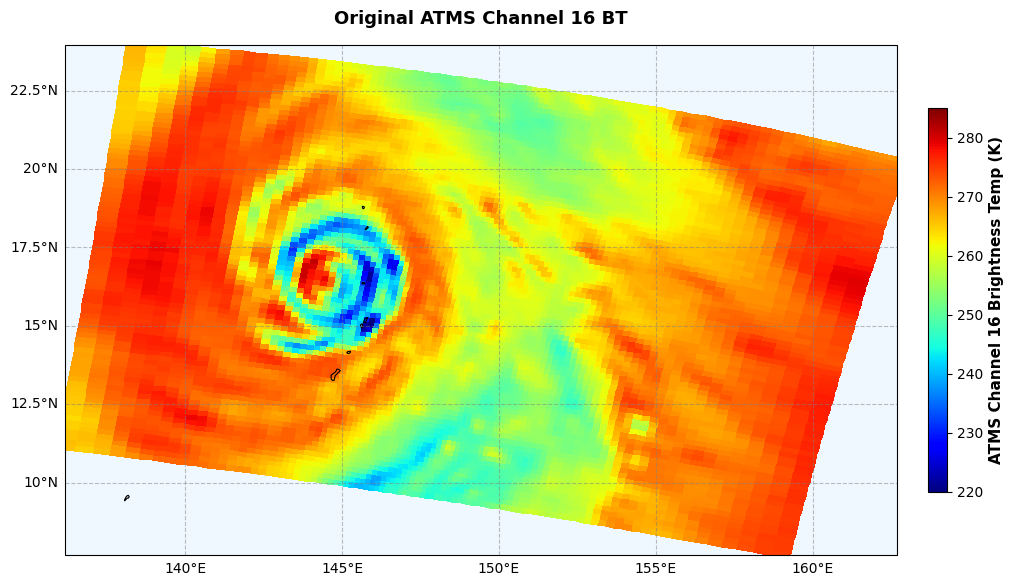

In [16]:
if RAW_ATMS_DATA_DIR.exists():
    atms_lon, atms_lat, atms_bt = read_raw_atms_channel16(RAW_ATMS_DATA_DIR)
    atms_extent = swath_extent(atms_lon, atms_lat)
    print("Raw ATMS BT shape:", atms_bt.shape)
    plot_atms_swath(atms_lon, atms_lat, atms_bt, "Original ATMS Channel 16 BT", extent=atms_extent)
else:
    print(f"Skipping raw ATMS case because {RAW_ATMS_DATA_DIR} does not exist.")


Prediction shape: (336, 384)


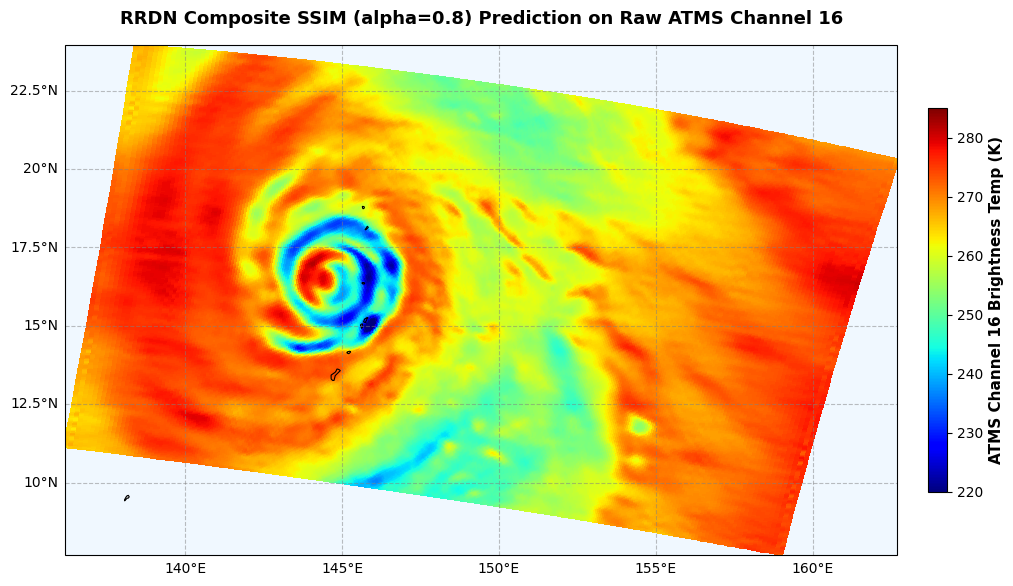

In [17]:
if RAW_ATMS_DATA_DIR.exists():
    atms_prediction = bundle.predict_kelvin(atms_bt, batch_size=1)
    pred_lat = zoom(atms_lat, 4, order=1)
    pred_lon = zoom(atms_lon, 4, order=1)
    print("Prediction shape:", atms_prediction.shape)
    plot_atms_swath(
        pred_lon, pred_lat, atms_prediction,
        f"{bundle.name} Prediction on Raw ATMS Channel 16",
        extent=atms_extent,
    )
else:
    print("Skipping raw ATMS prediction.")


## 7. Save a Prediction

For prepared HDF5 files that already contain a model-ready `bt` or `L/bt` dataset, the command-line prediction script is the recommended batch workflow. It loads the released model, applies the repository normalization statistics, writes model predictions back into HDF5, and preserves latitude/longitude fields when they exist.

```bash
python scripts/inference/make_prediction.py \
    --input sample_data/amsr2_example.h5 \
    --output outputs/example_keras_predictions.h5 \
    --artifact-format keras \
    --batch-size 1 \
    --overwrite \
    --strict
```

Then plot the saved prediction with longitude/latitude axes when geolocation variables are available:

```bash
python scripts/evaluation/plot_predictions.py \
    --input outputs/example_keras_predictions.h5 \
    --output-dir outputs/example_plots \
    --overwrite \
    --strict
```

### Using the `github_case` raw ATMS example

The `github_case/atms_example.py` script is different from `make_prediction.py`. It reads raw ATMS SDR/GEO files, applies the ATMS brightness-temperature scale factors, extracts channel 16, and plots the original swath. Use it when starting from raw `SATMS...h5` and `GATMO...h5` files rather than from a prepared model-input HDF5 file.

The raw files are stored under the project-root `data/` directory, run:

```bash
python github_case/atms_example.py
```

The current `github_case/atms_example.py` script makes an original ATMS map such as `orig.png`. It does not yet write model predictions into HDF5 the way `scripts/inference/make_prediction.py` does. For a full model-prediction workflow, first convert or prepare the raw ATMS channel-16 brightness temperature into a model-ready HDF5 file with a `bt` dataset, then run `make_prediction.py` on that prepared file.
